# Performance vs. truncation mode (same model)

Which part of the teacher trace should we keep when it is too long &mdash; the
**head**, **middle**, or **tail**? This notebook isolates that choice by comparing
truncation policies for the *same model at the same nominal character limit*,
holding the evaluation cap fixed at **8192 tokens**. At the nominal 24,000
setting, head retains up to 24,000 characters, middle retains a prefix of
18,000 plus a suffix of 6,000 for overlong traces, and tail retains 6,000.

Only the default-cap summary (`summary_reasoning_evals.json`) is used. The tail
policy also changes retained length. `(model, size)` groups are discovered from the
directory tree and **only groups with &ge; 2 modes present at the default cap are
kept**. Variant dirs without a default-cap summary (e.g. runs that only exist as
cap-variants) are skipped and logged. Headline metric per (model, size, mode) is
the **best-checkpoint accuracy** (max over epochs); accuracy-vs-epoch curves are
shown for context. Every epoch curve starts at the model's uncapped CoT
accuracy at epoch zero, loaded from `base_model/<model>_cot/mmlu_random_test/results.json`
as in `distillation_by_metrics.ipynb`. Dashed lines mark these base accuracies;
headline best-checkpoint scores still use only trained checkpoints.

Graph titles appear as separate notebook headings, outside copied images and PDF
exports. Legends sit above every graph; edit `LABELS` to customize readable names.
Former subplot grids are displayed as separate figures with their own headings.
All graphs are exported as PDFs to `artifacts/distillation_by_metrics/mmlu/plots/`,
with this notebook's name as a filename prefix. CSV tables keep their original
output directory.


In [29]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk up from `start` (cwd by default) until an `artifacts/` dir is found."""
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir():
            return d / "artifacts"
    raise FileNotFoundError("artifacts/ not found above cwd")


ARTIFACTS = find_artifacts_dir()
ROOT = ARTIFACTS.parent
if str(ROOT / "src") not in sys.path:  # make `core.*` importable when run top-to-bottom
    sys.path.insert(0, str(ROOT / "src"))

from core.utils.graph_style import set_style  # noqa: E402

set_style()

GROUP = "distillation_on_synthetic_traces"
DATASET = "mmlu"
SUBGROUP = "direct_reasoning_trace"
METRIC = "accuracy"
DEFAULT_CAP = 8192
MODE_ORDER = ["head", "middle", "tail"]
AGGREGATE_MODELS = ("llama_3b", "qwen_3b", "phi4_mini")
EVAL_KEY = "mmlu_random_test"
BASE_EXPERIMENT = "base_model"
BASE_SUFFIX = "_cot"
MODE_COLORS = {mode: plt.get_cmap("tab10")(i) for i, mode in enumerate(MODE_ORDER)}
SAVE = True  # export PDFs to PLOTS_DIR and CSVs to TABLES_DIR

SUBGROUP_DIR = ARTIFACTS / GROUP / DATASET / SUBGROUP
TABLES_DIR = ARTIFACTS / GROUP / DATASET / "plots"
PLOTS_DIR = ARTIFACTS / "distillation_by_metrics" / "mmlu" / "plots"
NOTEBOOK_NAME = "performance_vs_truncation_mode"
if SAVE:
    TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Edit this dictionary to customize graph labels and headings.
LABELS = {
    "llama_3b": "Llama 3B",
    "qwen_3b": "Qwen 3B",
    "phi4_mini": "Phi-4 Mini",
    "mmlu": "MMLU",
    "direct_reasoning_trace": "Direct reasoning trace",
    "head": "Head",
    "middle": "Middle",
    "tail": "Tail",
    "correct": "Correct",
    "incorrect": "Incorrect",
    "accuracy": "Accuracy",
    "base_model_cot": "Base model (CoT)",
    "base_model_cot_mean": "Base model (CoT) mean",
    "best_acc": "Best-checkpoint accuracy",
    "last_acc": "Last-checkpoint accuracy",
    "epoch": "Epoch",
    "reason_tokens": "Reasoning length (tokens)",
    "P50": "Median (P50)",
    "P90": "90th percentile (P90)",
    "P95": "95th percentile (P95)",
}
LEGEND_COLUMNS = 2  # wrap long legends into rows above each graph


def readable_label(key: str) -> str:
    return LABELS.get(key, key.replace("_", " ").capitalize())


def variant_label(variant: str, include_model: bool = True) -> str:
    if variant in LABELS:
        return LABELS[variant]
    match = re.fullmatch(r"(.+)_(head|middle|tail)_truncated(\d+)", variant)
    if not match:
        return readable_label(variant)
    model, mode, size = match.groups()
    label = f"{readable_label(mode)}"
    return f"{readable_label(model)} — {label}" if include_model else label


def show_plot(fig, ax, title: str, filename: str, extra_axes=()):
    """Display a separate heading and save a title-free PDF with its legend above."""
    handles, labels = ax.get_legend_handles_labels()
    for extra_ax in extra_axes:
        extra_handles, extra_labels = extra_ax.get_legend_handles_labels()
        handles.extend(extra_handles)
        labels.extend(extra_labels)
    fig.tight_layout()
    if handles:
        ax.legend(
            handles,
            labels,
            fontsize="small",
            loc="lower center",
            bbox_to_anchor=(0.5, 1.02),
            borderaxespad=0,
            ncol=min(LEGEND_COLUMNS, len(handles)),
            frameon=False,
        )
    if SAVE:
        PLOTS_DIR.mkdir(parents=True, exist_ok=True)
        plot_path = PLOTS_DIR / f"{NOTEBOOK_NAME}_{Path(filename).stem}.pdf"
        fig.savefig(plot_path, format="pdf", bbox_inches="tight")
    display(Markdown("### " + title.replace("\n", "<br>")))
    plt.show()
    plt.close(fig)


SUBGROUP_DIR


PosixPath('/Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_on_synthetic_traces/mmlu/direct_reasoning_trace')

In [30]:
DEFAULT_SUMMARY = "summary_reasoning_evals.json"
VARIANT_RE = re.compile(r"^(?P<model>.+)_(?P<mode>head|middle|tail)_truncated(?P<size>\d+)$")


def load_base(dataset_dir: Path, model: str) -> dict:
    """eval_key -> uncapped CoT accuracy, following distillation_by_metrics.ipynb."""
    base_dir = dataset_dir / BASE_EXPERIMENT / f"{model}{BASE_SUFFIX}"
    return {
        results.parent.name: json.loads(results.read_text())[METRIC]
        for results in sorted(base_dir.glob("*/results.json"))
    }


def with_base_anchor(points: list[tuple], base: dict, eval_key: str) -> list[tuple]:
    """Prepend the uncapped CoT score at zero, replacing any recorded epoch zero."""
    base_key = re.sub(r"_cap\d+$", "", eval_key)
    if base_key not in base:
        raise ValueError(f"Missing CoT anchor for {base_key}")
    return [(0.0, base[base_key])] + [(epoch, value) for epoch, value in points if epoch != 0]


def load_mode_groups(subgroup_dir: Path):
    """(model, size) -> mode -> sorted [(epoch, accuracy, num_truncated, total)].

    Uses only the default-cap summary (shared cap 8192) so the truncation mode is
    the only varying factor. Dirs lacking that file are skipped and logged. Returns
    (kept_groups, skipped_dirs, raw_groups) where kept_groups keeps only
    (model, size) groups with >= 2 distinct modes.
    """
    raw: dict = {}
    skipped: list = []
    for variant_dir in sorted(subgroup_dir.iterdir()):
        if not variant_dir.is_dir():
            continue
        m = VARIANT_RE.match(variant_dir.name)
        if not m:
            continue
        summary = variant_dir / DEFAULT_SUMMARY
        if not summary.is_file():
            skipped.append(variant_dir.name)
            continue
        content = json.loads(summary.read_text())
        records = content[EVAL_KEY]
        points = sorted(
            (r["epoch"], r[METRIC], r.get("num_truncated"), r.get("total"))
            for r in records
            if r.get("epoch") is not None and r.get(METRIC) is not None
        )
        if not points:
            continue
        key = (m.group("model"), int(m.group("size")))
        raw.setdefault(key, {})[m.group("mode")] = points

    kept = {k: v for k, v in raw.items() if len(v) >= 2}
    return kept, skipped, raw


mode_groups, skipped_dirs, raw_groups = load_mode_groups(SUBGROUP_DIR)
base_by_model = {
    model: load_base(SUBGROUP_DIR.parent, model)
    for model in sorted({model for model, _ in mode_groups} | set(AGGREGATE_MODELS))
}
for model, base in base_by_model.items():
    if EVAL_KEY not in base:
        raise ValueError(f"Missing uncapped CoT anchor for {model}/{EVAL_KEY}")

print(f"Groups with >= 2 truncation modes at default cap {DEFAULT_CAP} ({len(mode_groups)}):")
for (model, size), modes in sorted(mode_groups.items()):
    present = [m for m in MODE_ORDER if m in modes]
    print(f"  {model} @ {size}: {present}")

dropped = {k: sorted(v) for k, v in raw_groups.items() if len(v) < 2}
if dropped:
    print("\nGroups with only one comparable mode at the default cap (excluded):")
    for (model, size), modes in sorted(dropped.items()):
        print(f"  {model} @ {size}: {modes}")
if skipped_dirs:
    print("\nVariant dirs skipped (no default-cap summary, e.g. cap-only runs):")
    for name in skipped_dirs:
        print(f"  {name}")


Groups with >= 2 truncation modes at default cap 8192 (3):
  llama_3b @ 24000: ['head', 'middle', 'tail']
  phi4_mini @ 24000: ['head', 'middle', 'tail']
  qwen_3b @ 24000: ['head', 'middle', 'tail']

Groups with only one comparable mode at the default cap (excluded):
  llama_3b @ 8192: ['head']
  phi4_mini @ 8192: ['head']
  qwen_3b @ 8192: ['head']

Variant dirs skipped (no default-cap summary, e.g. cap-only runs):
  llama_3b_head_truncated3072
  phi4_mini_head_truncated3072
  qwen_3b_head_truncated3072


In [31]:
rows = []
for (model, size), modes in mode_groups.items():
    for mode, points in modes.items():
        best_epoch, best_acc, best_trunc, best_total = max(points, key=lambda p: p[1])
        rows.append(
            {
                "model": model,
                "size": size,
                "mode": mode,
                "best_acc": best_acc,
                "epoch_at_best": best_epoch,
                "num_truncated_at_best": best_trunc,
            }
        )

mode_best_df = pd.DataFrame(rows)
mode_best_df["mode"] = pd.Categorical(mode_best_df["mode"], categories=MODE_ORDER, ordered=True)
mode_best_df = mode_best_df.sort_values(["model", "size", "mode"]).reset_index(drop=True)
if SAVE:
    mode_best_df.to_csv(TABLES_DIR / "mode_best_checkpoint.csv", index=False)
mode_best_df


,model,size,mode,best_acc,epoch_at_best,num_truncated_at_best
0,llama_3b,24000,head,0.459268,20.0,2
1,llama_3b,24000,middle,0.445553,20.0,18
2,llama_3b,24000,tail,0.449709,5.0,26
3,phi4_mini,24000,head,0.543641,5.0,398
4,phi4_mini,24000,middle,0.560682,20.0,398
5,phi4_mini,24000,tail,0.573566,5.0,308
6,qwen_3b,24000,head,0.509559,15.0,2
7,qwen_3b,24000,middle,0.504156,20.0,1
8,qwen_3b,24000,tail,0.497091,10.0,15


### Accuracy by truncation mode (same model & size)

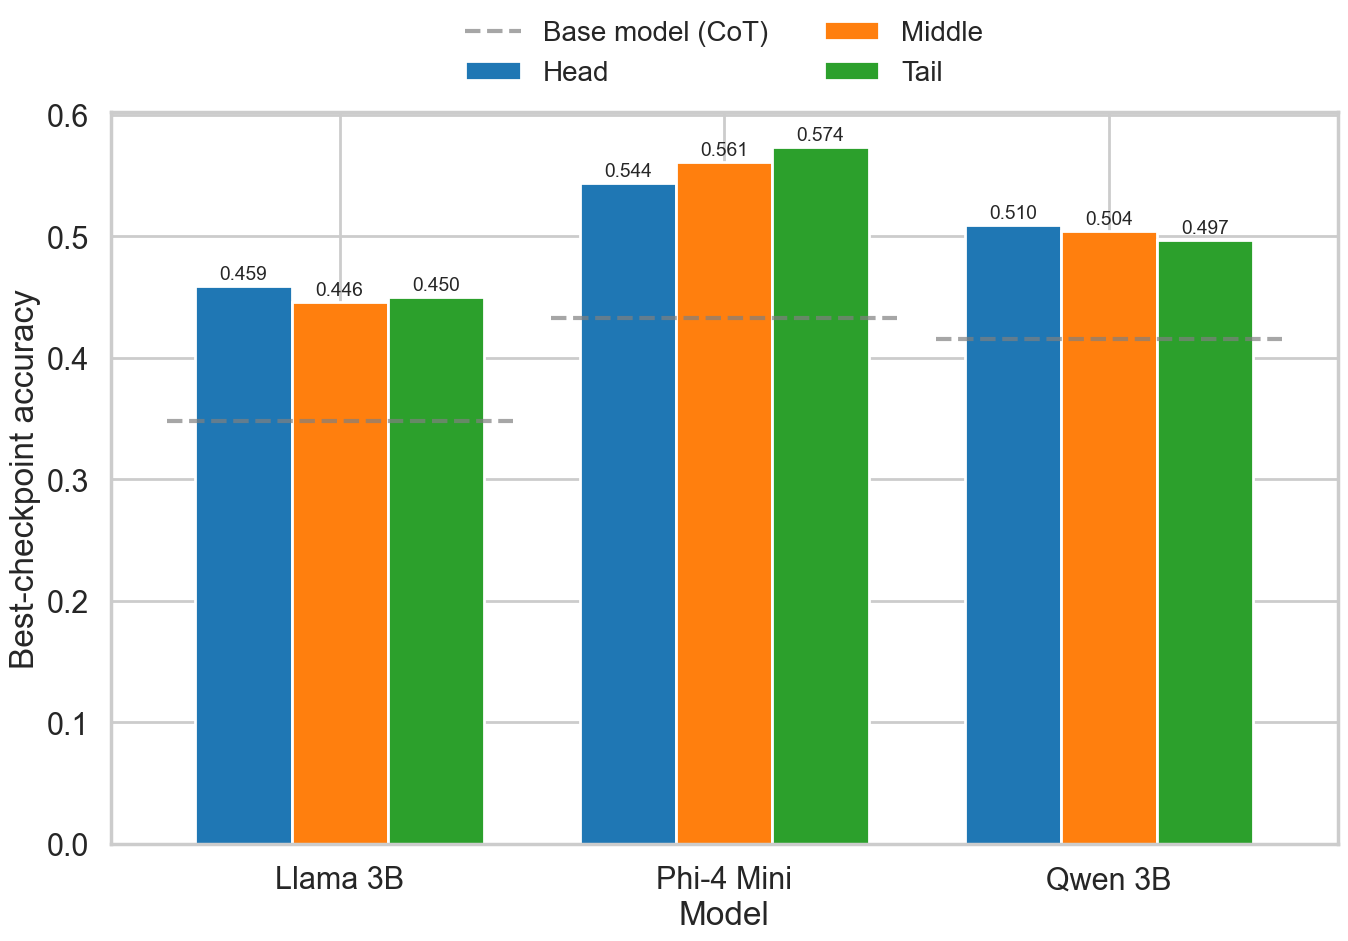

In [32]:
group_keys = sorted(mode_groups)
labels = [f"{readable_label(model)}" for model, size in group_keys]
x = np.arange(len(group_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 9))
for i, mode in enumerate(MODE_ORDER):
    vals = []
    for model, size in group_keys:
        row = mode_best_df[
            (mode_best_df["model"] == model) & (mode_best_df["size"] == size) & (mode_best_df["mode"] == mode)
        ]
        vals.append(row["best_acc"].iloc[0] if len(row) else np.nan)
    offset = (i - (len(MODE_ORDER) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=readable_label(mode), color=MODE_COLORS[mode])
    lbls = ["" if not np.isfinite(v) else f"{v:.3f}" for v in vals]
    ax.bar_label(bars, labels=lbls, fontsize="xx-small", padding=2)
for index, (model, size) in enumerate(group_keys):
    acc = base_by_model[model][EVAL_KEY]
    ax.plot(
        [index - 0.45, index + 0.45], [acc, acc], ls="--", color="gray", alpha=0.7,
        label=readable_label("base_model_cot") if index == 0 else "_nolegend_",
    )
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(readable_label("best_acc"))
ax.set_xlabel("Model")
show_plot(fig, ax, "Accuracy by truncation mode (same model & size)", "mode_best_acc_bars.pdf")


### Accuracy across epochs, per truncation mode — Llama 3B — 24,000 tokens

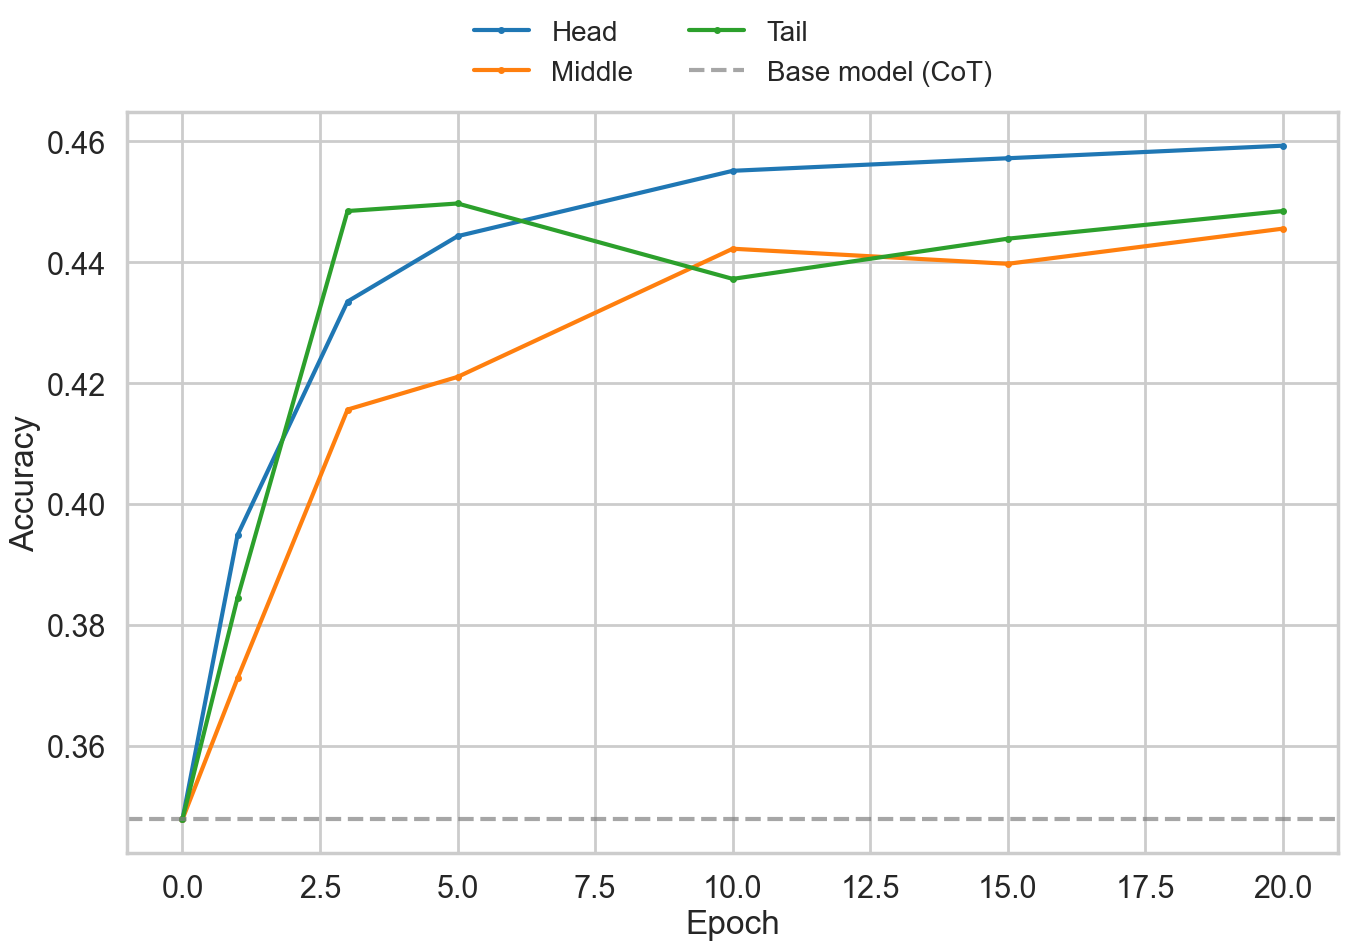

### Accuracy across epochs, per truncation mode — Phi-4 Mini — 24,000 tokens

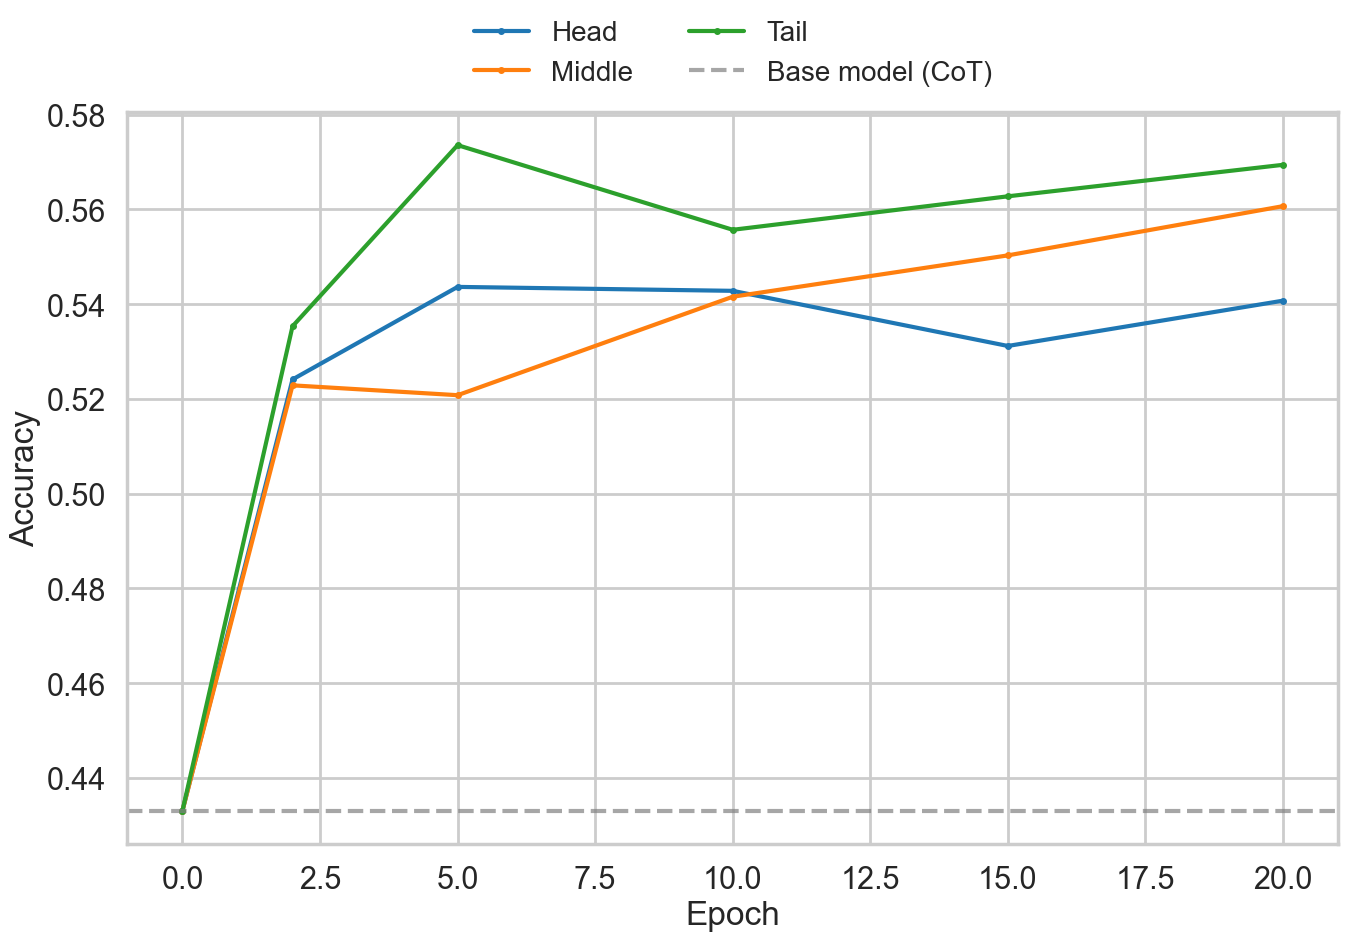

### Accuracy across epochs, per truncation mode — Qwen 3B — 24,000 tokens

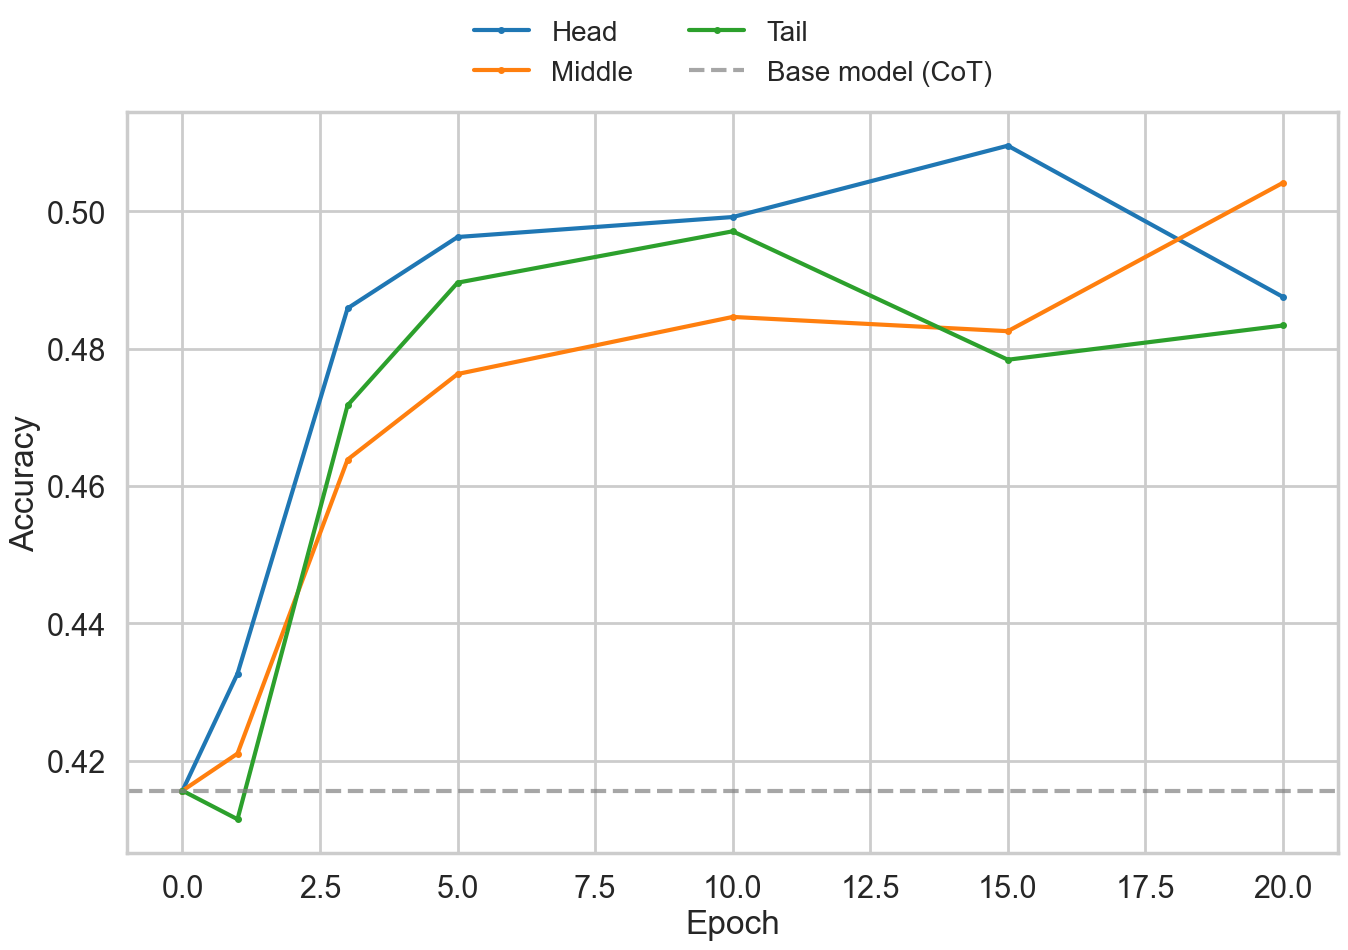

In [33]:
group_keys = sorted(mode_groups)
for model, size in group_keys:
    fig, ax = plt.subplots(figsize=(14, 9))
    for mode in MODE_ORDER:
        if mode not in mode_groups[(model, size)]:
            continue
        points = with_base_anchor(
            [(epoch, acc) for epoch, acc, *_ in mode_groups[(model, size)][mode]],
            base_by_model[model], EVAL_KEY,
        )
        xs = [epoch for epoch, _ in points]
        ys = [acc for _, acc in points]
        ax.plot(xs, ys, marker="o", ms=4, label=readable_label(mode), color=MODE_COLORS[mode])
    ax.axhline(
        base_by_model[model][EVAL_KEY], ls="--", color="gray", alpha=0.7,
        label=readable_label("base_model_cot"),
    )
    ax.set_xlabel(readable_label("epoch"))
    ax.set_ylabel(readable_label(METRIC))
    show_plot(
        fig,
        ax,
        f"Accuracy across epochs, per truncation mode — {readable_label(model)} — {size:,} characters",
        f"mode_accuracy_vs_epoch_{model}_truncated{size}.pdf",
    )


## Truncation modes averaged across all models

These figures give Llama 3B, Qwen 3B, and Phi-4 Mini equal weight. Only
`(truncation size, mode)` combinations available for all three models are used,
and a size must have at least two such modes. Evaluation remains at cap **8192**.

The bar chart averages each model's **best trained-checkpoint accuracy**; the
models can reach their best scores at different epochs. The epoch graphs average
CoT-anchored curves at the union of their observed epochs within the shared
range, using linear interpolation without extrapolation. Every averaged curve
starts at the mean of the three uncapped CoT scores at epoch zero.

In [34]:
def aggregate_model_points(model_points: dict, required_models: set[str]) -> list[tuple]:
    """Interpolate within the shared epoch range and weight every model equally."""
    missing = required_models - set(model_points)
    if missing:
        raise ValueError(f"Cannot aggregate across all models; missing {sorted(missing)}")
    if not required_models or any(not model_points[model] for model in required_models):
        return []
    arrays = {}
    for model in sorted(required_models):
        points = sorted(model_points[model])
        xs = np.asarray([epoch for epoch, _ in points], dtype=float)
        ys = np.asarray([value for _, value in points], dtype=float)
        if len(set(xs)) != len(xs):
            raise ValueError(f"Duplicate epoch for {model}")
        arrays[model] = (xs, ys)
    lower = max(xs[0] for xs, _ in arrays.values())
    upper = min(xs[-1] for xs, _ in arrays.values())
    epochs = sorted({epoch for xs, _ in arrays.values() for epoch in xs if lower <= epoch <= upper})
    return [
        (float(epoch), float(np.mean([np.interp(epoch, xs, ys) for xs, ys in arrays.values()])))
        for epoch in epochs
    ]


required_models = set(AGGREGATE_MODELS)
aggregate_groups = {}
for size in sorted({size for _, size in mode_groups}):
    complete_modes = {}
    for mode in MODE_ORDER:
        model_points = {
            model: with_base_anchor(
                [(epoch, acc) for epoch, acc, *_ in mode_groups[(model, size)][mode]],
                base_by_model[model], EVAL_KEY,
            )
            for model in AGGREGATE_MODELS
            if (model, size) in mode_groups and mode in mode_groups[(model, size)]
        }
        if set(model_points) == required_models:
            complete_modes[mode] = model_points
    if len(complete_modes) >= 2:
        aggregate_groups[size] = complete_modes
    else:
        print(f"Excluded all-model mean at {size:,} characters: fewer than two modes shared by all models")

mean_base = float(np.mean([base_by_model[model][EVAL_KEY] for model in AGGREGATE_MODELS]))
aggregate_rows = []
for size, modes in sorted(aggregate_groups.items()):
    for mode in MODE_ORDER:
        if mode not in modes:
            continue
        scores = mode_best_df[
            mode_best_df["model"].isin(required_models)
            & mode_best_df["size"].eq(size)
            & mode_best_df["mode"].eq(mode)
        ]
        assert set(scores["model"]) == required_models
        aggregate_rows.append({
            "size": size, "mode": mode, "num_models": len(required_models),
            "mean_best_acc": float(scores["best_acc"].mean()), "base_cot_mean": mean_base,
        })
aggregate_best_df = pd.DataFrame(
    aggregate_rows, columns=["size", "mode", "num_models", "mean_best_acc", "base_cot_mean"],
)
if SAVE:
    aggregate_best_df.to_csv(TABLES_DIR / "mode_all_models_best_checkpoint.csv", index=False)
display(aggregate_best_df)


,size,mode,num_models,mean_best_acc,base_cot_mean
0,24000,head,3,0.504156,0.398864
1,24000,middle,3,0.503464,0.398864
2,24000,tail,3,0.506789,0.398864


### Accuracy by truncation mode — all-model mean (3 models)

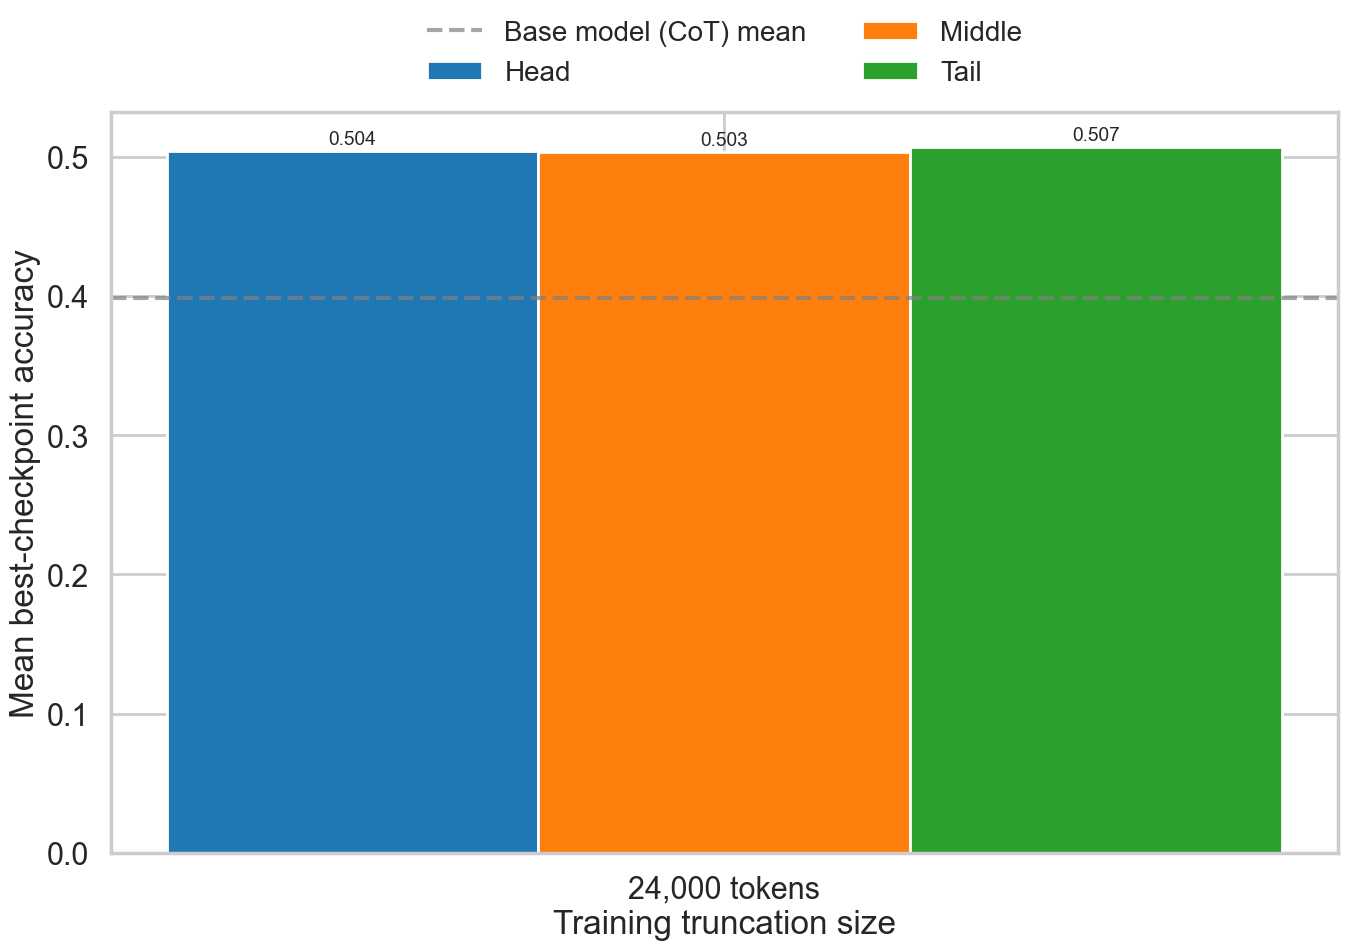

In [35]:
if aggregate_groups:
    sizes = sorted(aggregate_groups)
    x = np.arange(len(sizes))
    width = 0.25
    fig, ax = plt.subplots(figsize=(14, 9))
    for index, mode in enumerate(MODE_ORDER):
        vals = []
        for size in sizes:
            row = aggregate_best_df[
                aggregate_best_df["size"].eq(size) & aggregate_best_df["mode"].eq(mode)
            ]
            vals.append(row["mean_best_acc"].iloc[0] if len(row) else np.nan)
        offset = (index - (len(MODE_ORDER) - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=readable_label(mode), color=MODE_COLORS[mode])
        ax.bar_label(
            bars, labels=["" if not np.isfinite(value) else f"{value:.3f}" for value in vals],
            fontsize="xx-small", padding=2,
        )
    ax.axhline(mean_base, ls="--", color="gray", alpha=0.7, label=readable_label("base_model_cot_mean"))
    ax.set_xticks(x, labels=[f"{size:,} characters" for size in sizes])
    ax.set_xlabel("Training truncation size")
    ax.set_ylabel("Mean best-checkpoint accuracy")
    show_plot(
        fig, ax, f"Accuracy by truncation mode — all-model mean ({len(required_models)} models)",
        "mode_all_models_best_acc_bars.pdf",
    )


### Accuracy across epochs, per truncation mode — all-model mean (3 models) — 24,000 tokens

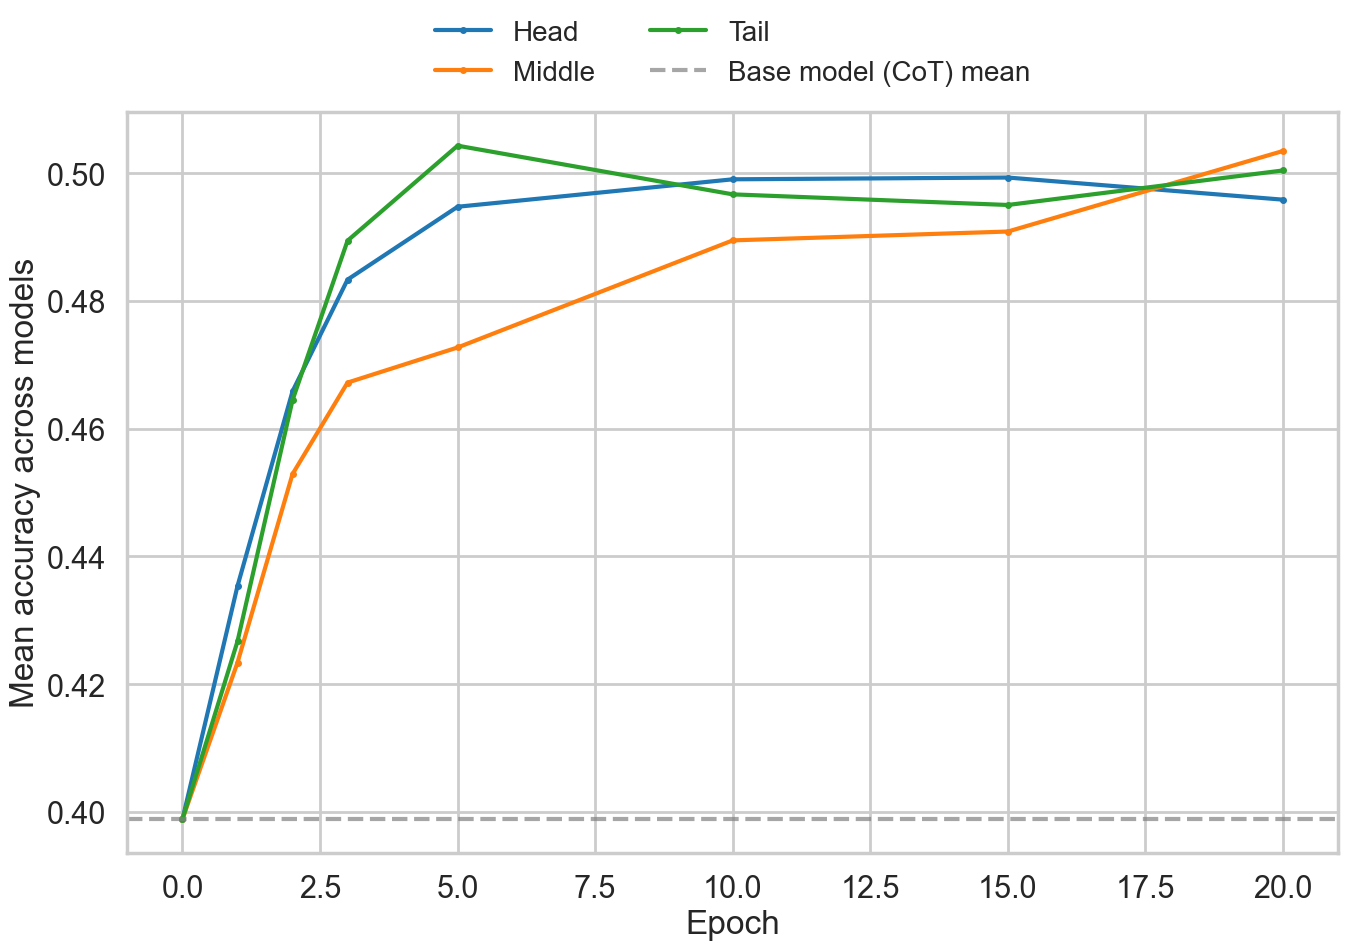

In [36]:
for size, modes in sorted(aggregate_groups.items()):
    fig, ax = plt.subplots(figsize=(14, 9))
    for mode in MODE_ORDER:
        if mode not in modes:
            continue
        points = aggregate_model_points(modes[mode], required_models)
        ax.plot(
            [epoch for epoch, _ in points], [acc for _, acc in points],
            marker="o", ms=4, color=MODE_COLORS[mode], label=readable_label(mode),
        )
    ax.axhline(mean_base, ls="--", color="gray", alpha=0.7, label=readable_label("base_model_cot_mean"))
    ax.set_xlabel(readable_label("epoch"))
    ax.set_ylabel("Mean accuracy across models")
    show_plot(
        fig, ax,
        f"Accuracy across epochs, per truncation mode — all-model mean ({len(required_models)} models) — {size:,} characters",
        f"mode_all_models_accuracy_vs_epoch_truncated{size}.pdf",
    )


## Takeaways

- The **grouped bar chart** is the headline: for each `(model, size)` group it puts
  the truncation modes side by side, so the best-performing way to truncate a long
  trace is the tallest bar. Missing bars are modes that were not run at the shared
  default cap.
- The **per-mode epoch curves** show whether a mode's advantage holds across
  training or only at a single checkpoint.
- Coverage is intentionally narrow: only `(model, size)` groups with &ge; 2 modes at
  the default cap qualify. The loader printout above lists exactly what was included
  and what was dropped (and why), so nothing is silently omitted.
